In [25]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

In [3]:
# Calculate sample size
def calculate_sample_size(baseline_conversion, expected_lift, alpha=0.05, power=0.8, exposure_rate=0.5):
    "Calculates total sample size for an A/B test using a Z-test for proportions."
    from scipy.stats import norm

    # Conversion rates
    p1 = baseline_conversion
    p2 = baseline_conversion + expected_lift

    # Z-scores
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)

    # Pooled standard error
    pooled_se = np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))

    # Effect size
    delta = abs(p2 - p1)

    # Adjustment factor for unequal split
    adjustment = 1 / (exposure_rate * (1 - exposure_rate))

    # Total sample size
    n_total = ((z_alpha + z_beta) ** 2 * pooled_se**2) / delta**2
    n_total_adjusted = int(np.ceil(n_total * adjustment))

    return n_total_adjusted

In [14]:
# Experiment baseline parameters
baseline_conversion=0.1
expected_lift=0.01
exposure_rate=0.05
alpha=0.05
power=0.8

# List of exposure rates (5% to 50% in 5% steps)
exposure_rates = np.arange(0.05, 0.55, 0.05)

results = []
for exposure_rate in exposure_rates:
    n_users = calculate_sample_size(
        baseline_conversion=baseline_conversion,
        expected_lift=expected_lift,
        alpha=alpha,
        power=power,
        exposure_rate=exposure_rate)

    # Append result
    results.append({
    'Baseline Conversion': f"{baseline_conversion * 100:.0f}%",
    'Expected Lift': f"{expected_lift * 100:.0f}%",
    'Exposure Rate': f"{exposure_rate * 100:.0f}%",
    'Alpha': f"{alpha * 100:.0f}%",
    'Power': f"{power * 100:.0f}%",
    'Required Users': f"{n_users:,}"
    })

# Convert to DataFrame
df_sample_sizes_exposure = pd.DataFrame(results)
df_sample_sizes_exposure

,Baseline Conversion,Expected Lift,Exposure Rate,Alpha,Power,Required Users
0,10%,1%,5%,5%,80%,"310,486"
1,10%,1%,10%,5%,80%,"163,868"
2,10%,1%,15%,5%,80%,"115,671"
3,10%,1%,20%,5%,80%,"92,176"
4,10%,1%,25%,5%,80%,"78,657"
5,10%,1%,30%,5%,80%,"70,229"
6,10%,1%,35%,5%,80%,"64,827"
7,10%,1%,40%,5%,80%,"61,451"
8,10%,1%,45%,5%,80%,"59,589"
9,10%,1%,50%,5%,80%,"58,993"


In [16]:
# Experiment baseline parameters
baseline_conversion=0.1
expected_lift=0.01
exposure_rate=0.05
alpha=0.05
power=0.8

# List of expected lifts (1% to 10% in 1% steps)
expected_lift = np.arange(0.01, 0.11, 0.01)

results = []
for expected_lift in expected_lift:
    n_users = calculate_sample_size(
        baseline_conversion=baseline_conversion,
        expected_lift=expected_lift,
        alpha=alpha,
        power=power,
        exposure_rate=exposure_rate)

    # Append result
    results.append({
    'Baseline Conversion': f"{baseline_conversion * 100:.0f}%",
    'Expected Lift': f"{expected_lift * 100:.0f}%",
    'Exposure Rate': f"{exposure_rate * 100:.0f}%",
    'Alpha': f"{alpha * 100:.0f}%",
    'Power': f"{power * 100:.0f}%",
    'Required Users': f"{n_users:,}"
    })

# Convert to DataFrame
df_sample_sizes_lift = pd.DataFrame(results)
df_sample_sizes_lift

,Baseline Conversion,Expected Lift,Exposure Rate,Alpha,Power,Required Users
0,10%,1%,5%,5%,80%,"310,486"
1,10%,2%,5%,5%,80%,"80,803"
2,10%,3%,5%,5%,80%,"37,290"
3,10%,4%,5%,5%,80%,"21,730"
4,10%,5%,5%,5%,80%,"14,376"
5,10%,6%,5%,5%,80%,"10,300"
6,10%,7%,5%,5%,80%,"7,794"
7,10%,8%,5%,5%,80%,"6,135"
8,10%,9%,5%,5%,80%,"4,976"
9,10%,10%,5%,5%,80%,"4,131"


In [17]:
# Experiment baseline parameters
baseline_conversion=0.1
expected_lift=0.01
exposure_rate=0.05
alpha=0.05
power=0.8

# List of alphas (1% to 10% in 1% steps)
alpha = np.arange(0.01, 0.11, 0.01)

results = []
for alpha in alpha:
    n_users = calculate_sample_size(
        baseline_conversion=baseline_conversion,
        expected_lift=expected_lift,
        alpha=alpha,
        power=power,
        exposure_rate=exposure_rate)

    # Append result
    results.append({
    'Baseline Conversion': f"{baseline_conversion * 100:.0f}%",
    'Expected Lift': f"{expected_lift * 100:.0f}%",
    'Exposure Rate': f"{exposure_rate * 100:.0f}%",
    'Alpha': f"{alpha * 100:.0f}%",
    'Power': f"{power * 100:.0f}%",
    'Required Users': f"{n_users:,}"
    })

# Convert to DataFrame
df_sample_sizes_alpha = pd.DataFrame(results)
df_sample_sizes_alpha

,Baseline Conversion,Expected Lift,Exposure Rate,Alpha,Power,Required Users
0,10%,1%,5%,1%,80%,"461,996"
1,10%,1%,5%,2%,80%,"397,005"
2,10%,1%,5%,3%,80%,"358,807"
3,10%,1%,5%,4%,80%,"331,621"
4,10%,1%,5%,5%,80%,"310,486"
5,10%,1%,5%,6%,80%,"293,186"
6,10%,1%,5%,7%,80%,"278,537"
7,10%,1%,5%,8%,80%,"265,832"
8,10%,1%,5%,9%,80%,"254,614"
9,10%,1%,5%,10%,80%,"244,569"


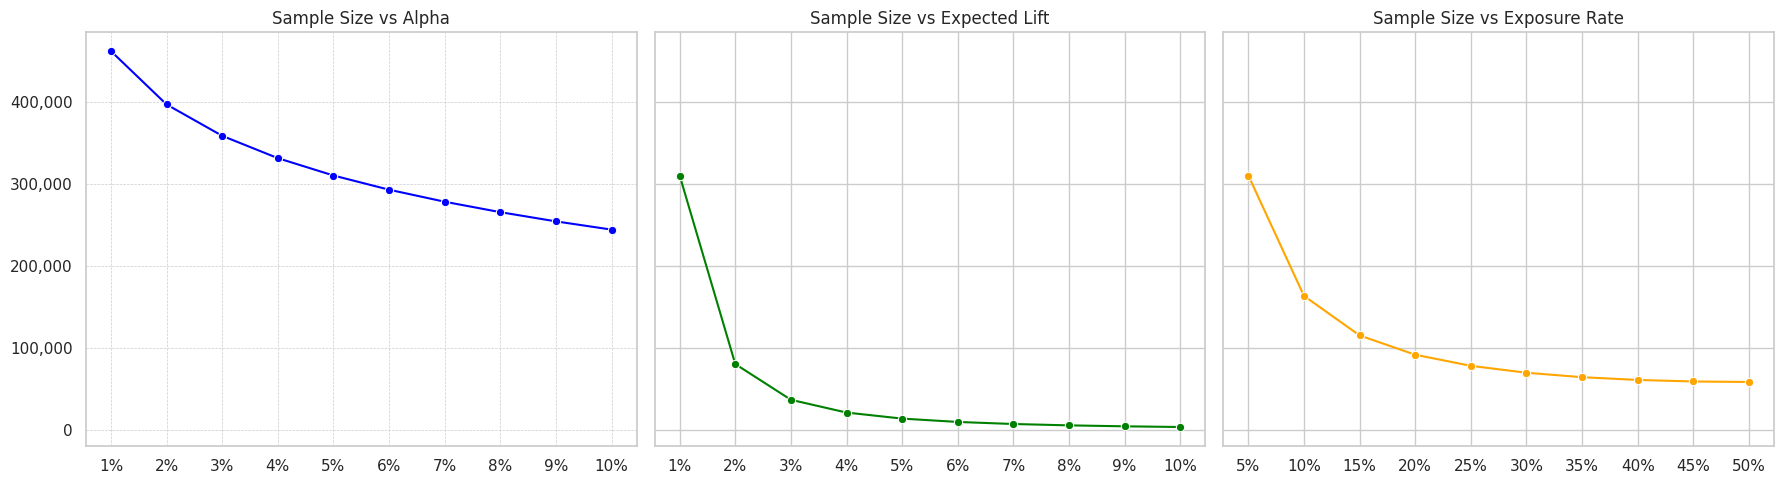

In [32]:
from matplotlib.ticker import LogLocator, StrMethodFormatter

# Convert formatted numbers back to integers
df_sample_sizes_alpha['Required Users'] = df_sample_sizes_alpha['Required Users'].astype(int)
df_sample_sizes_lift['Required Users'] = df_sample_sizes_lift['Required Users'].astype(int)
df_sample_sizes_exposure['Required Users'] = df_sample_sizes_exposure['Required Users'].astype(int)

# Set plot style
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

custom_log_base = 2.5

# Plot 1: Alpha vs Required Users
sns.lineplot(
    x='Alpha', y='Required Users', data=df_sample_sizes_alpha, marker='o', ax=axes[0], color='blue'
)
axes[0].set_title("Sample Size vs Alpha")
axes[0].set_ylabel("")
axes[0].set_xlabel("")
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Plot 2: Expected Lift vs Required Users
sns.lineplot(
    x='Expected Lift', y='Required Users', data=df_sample_sizes_lift, marker='o', ax=axes[1], color='green'
)
axes[1].set_title("Sample Size vs Expected Lift")
axes[1].set_xlabel("")

# Plot 3: Exposure Rate vs Required Users
sns.lineplot(
    x='Exposure Rate', y='Required Users', data=df_sample_sizes_exposure, marker='o', ax=axes[2], color='orange'
)
axes[2].set_title("Sample Size vs Exposure Rate")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()